In [ ]:
from datasets import load_dataset
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt

dataset = load_dataset("oxai4science/sdoml-lite", streaming=True)

Resolving data files:   0%|          | 0/5194 [00:00<?, ?it/s]

In [ ]:
channels = ['hmi_m', 'aia_0131', 'aia_0171', 'aia_0193', 'aia_0211', 'aia_1600']

def process(data):
    timestamp = datetime.strptime(data['__key__'], "%Y/%m/%d/%H%M")
    d = []
    for c in map(lambda x: x+'.npy', channels):
        d.append(np.array(data[c]) if c in data else np.zeros((512, 512)))
    return timestamp, np.stack(d, axis=0)

def plot(timestamp, data):
    import matplotlib.pyplot as plt
    _, axs = plt.subplots(2, 3, figsize=(15, 10))
    axs = axs.flatten()
    for i, c in enumerate(channels):
        axs[i].imshow(data[i], cmap='gray')
        axs[i].set_title(c)
        axs[i].axis('off')
    plt.tight_layout()
    plt.suptitle(timestamp)
    plt.subplots_adjust(top=0.94)
    plt.show()

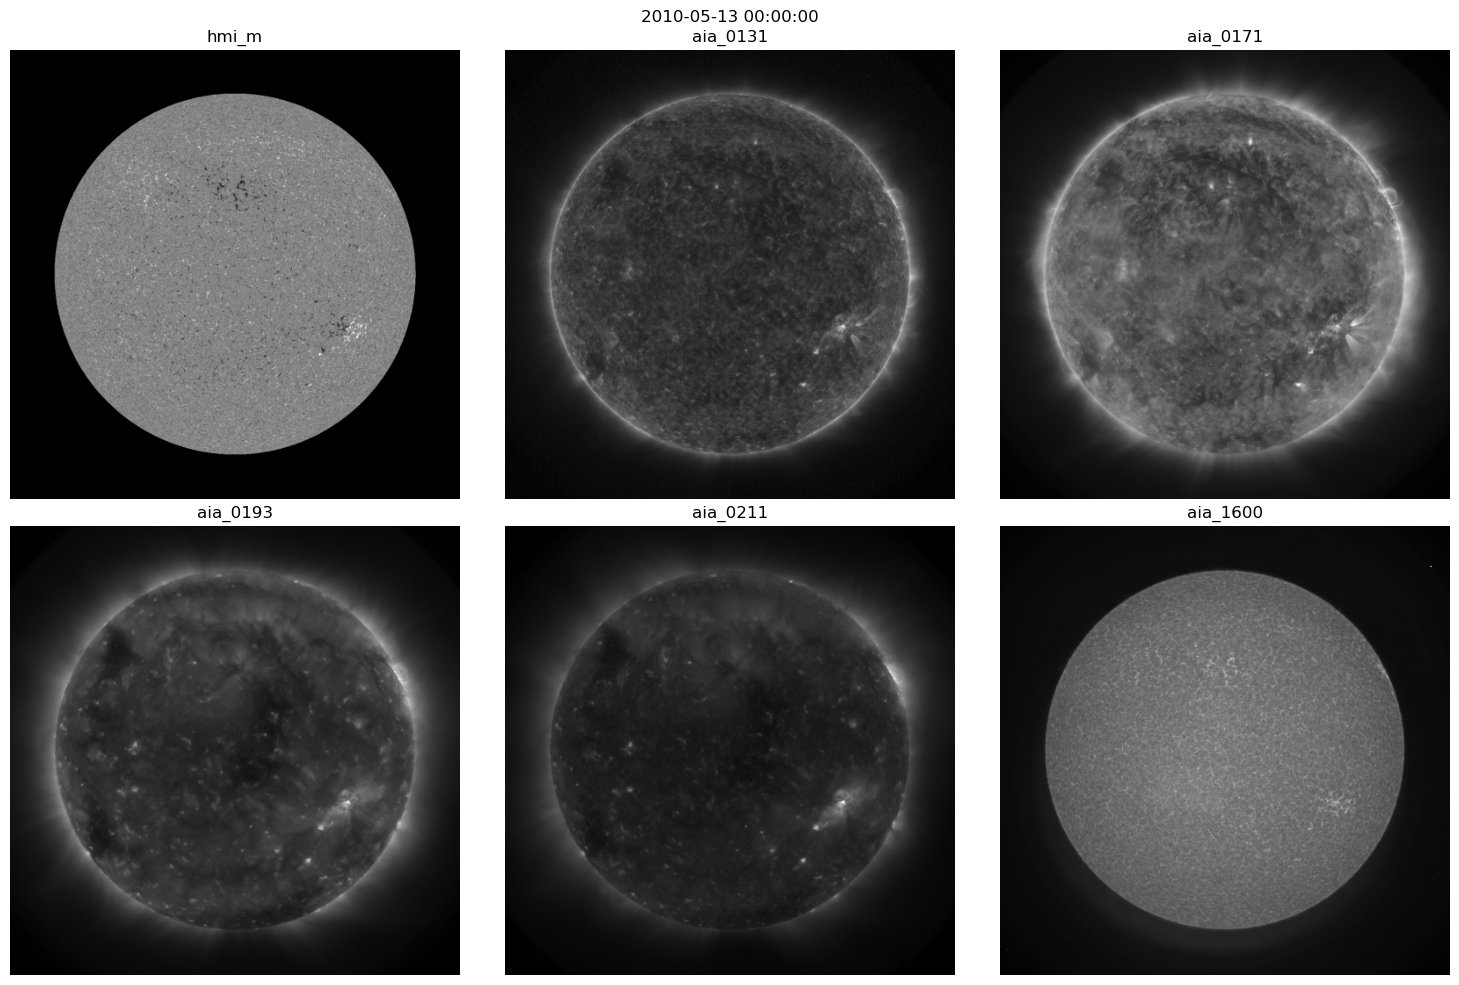

In [96]:
sample  = next(iter(dataset['train']))
timestamp, data = process(sample)
plot(timestamp, data)
